# 📘 Lecture 12: Exponential Families, Maximum Entropy, Mixture Models (GMM/BMM), & Graphical Models (PGM)
**Course**: Probabilistic Machine Learning by Aayush  
**Video Reference**: [Lecture 12 - YouTube](https://youtu.be/T1uTBtJ7aHU?si=NKY__ivKTKLrR0GA)

---
### 📌 Executive Overview & Core Objectives
In this lecture, we complete our foundations of probabilistic machine learning across three major pillars:
1. **Exponential Family of Distributions**: Mathematical definition $p(\mathbf{y} \mid \boldsymbol{\eta}) = h(\mathbf{y}) \exp(\boldsymbol{\eta}^\top \mathbf{T}(\mathbf{y}) - A(\boldsymbol{\eta}))$, proving why Sigmoid $\mu = \sigma(\eta) = \frac{1}{1 + e^{-\eta}}$ naturally emerges from the Bernoulli distribution, and demonstrating how derivatives of the log-partition function $A(\boldsymbol{\eta})$ generate all distribution cumulants (Mean & Covariance).
2. **Convexity & Maximum Entropy (MaxEnt)**: Proving that log-partition Hessian $\nabla^2 A(\boldsymbol{\eta}) = \text{Cov}(\mathbf{T}(\mathbf{y})) \succeq 0$ ensures a unique global maximum for MLE, and using Lagrangian calculus to prove that MaxEnt under fixed moment constraints yields the Exponential Family.
3. **Mixture Models (GMM & BMM)**: Formulation of $P(\mathbf{y}) = \sum_{k=1}^K \pi_k p_k(\mathbf{y})$, calculating soft posterior responsibilities $r_{nk} = P(z_n = k \mid \mathbf{y}_n)$, proving that hard spherical GMM clustering reduces to K-Means, and implementing Bernoulli Mixture Models for binary image clustering.
4. **Probabilistic Graphical Models (PGMs) & Markov Chains**: Directed Acyclic Graphs (DAGs), Bayesian Networks, Ordered Markov Property $P(\mathbf{y}) = \prod P(y_i \mid \text{Parents}(y_i))$, Berkson's Paradox (Explaining Away), Plate Notation, and $N$-gram Language Models.

---


## 0️⃣ Environment Setup & Imports
We start by importing scientific computation, optimization, and visualization packages.

In [1]:
#Start code here..
import numpy as np
import pandas as pd
import scipy.stats as stats
import scipy.optimize as opt
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
print("Libraries imported successfully! Numpy version:", np.__version__)
#End code here..


Libraries imported successfully! Numpy version: 2.1.3


## 1️⃣ Exponential Family & Bernoulli Sigmoid Derivation

### 1.1 General Exponential Family Canonical Form
A probability distribution belongs to the Exponential Family if its density can be written as:
$$p(\mathbf{y} \mid \boldsymbol{\eta}) = h(\mathbf{y}) \exp\left( \boldsymbol{\eta}^\top \mathbf{T}(\mathbf{y}) - A(\boldsymbol{\eta}) \right)$$
- $h(\mathbf{y})$: Base measure (scaling constant).
- $\boldsymbol{\eta}$: Natural / canonical parameter vector.
- $\mathbf{T}(\mathbf{y})$: Sufficient statistics vector.
- $A(\boldsymbol{\eta}) = \log Z(\boldsymbol{\eta})$: Log-partition function (cumulant generator).

### 1.2 Mathematical Derivation: Bernoulli to Sigmoid Link
The Bernoulli PMF for binary $y \in \{0, 1\}$ with mean parameter $\mu \in (0, 1)$ is:
$$P(y \mid \mu) = \mu^y (1 - \mu)^{1 - y} = \exp\left( \log\left( \mu^y (1 - \mu)^{1 - y} \right) \right) = \exp\left( y \log\frac{\mu}{1 - \mu} + \log(1 - \mu) \right)$$

Comparing with $h(y) \exp(\eta T(y) - A(\eta))$:
- Base measure: $h(y) = 1$
- Sufficient statistic: $T(y) = y$
- **Natural Parameter**: $\eta = \log \frac{\mu}{1 - \mu}$ (Log-odds / Logit)
- **Log-Partition Function**: $A(\eta) = -\log(1 - \mu) = \log(1 + e^\eta)$

Inverting $\eta = \log \frac{\mu}{1 - \mu}$ for mean parameter $\mu$ yields the **Sigmoid / Logistic Function**:
$$\mu = \frac{1}{1 + e^{-\eta}} = \sigma(\eta)$$

### 1.3 Cumulant Generation via Derivatives of $A(\eta)$
- First derivative: $\nabla_\eta A(\eta) = \frac{d}{d\eta} \log(1 + e^\eta) = \frac{e^\eta}{1 + e^\eta} = \mu = \mathbb{E}[T(y)]$.
- Second derivative: $\nabla_\eta^2 A(\eta) = \frac{d}{d\eta} \sigma(\eta) = \sigma(\eta)(1 - \sigma(\eta)) = \text{Var}(y)$.

In [2]:
#Start code here...
#Code verification of cumulant generation and sigmoid inversion
eta_val = 1.5 #natural parameter logit
#log partition function
def A_bern(eta):
    return np.log(1.0 + np.exp(eta))
#Numerical derivatives.
eps = 1e-5
grad_A = (A_bern(eta_val + eps) - A_bern(eta_val - eps)) / (2*eps)
hess_A = (A_bern(eta_val + eps) - 2*A_bern(eta_val) + A_bern(eta_val - eps)) / (eps**2)

#Analytical sigmoid and variance
mu_analytical = 1.0 / (1.0 + np.exp(-eta_val))
var_analytical = mu_analytical * (1.0 - mu_analytical)

print("Bernoulli Exponential family cumulant verification:")
print(f" Natural parameter eta : {eta_val:.4f}")
print(f" Gradient dA(eta)/deta (Expected mean E[y]): {grad_A:.4f}, Analytical Sigmoid: {mu_analytical:.4f}")
print(f" Hessian d^2A(eta)/deta^2 (Expected variance Var[y]): {hess_A:.4f}, Analytical variance: {var_analytical:.4f})")


#End code here..


Bernoulli Exponential family cumulant verification:
 Natural parameter eta : 1.5000
 Gradient dA(eta)/deta (Expected mean E[y]): 0.8176, Analytical Sigmoid: 0.8176
 Hessian d^2A(eta)/deta^2 (Expected variance Var[y]): 0.1491, Analytical variance: 0.1491)


## 2️⃣ Maximum Entropy (MaxEnt) Derivation of Exponential Family

### 2.1 Principle of Maximum Entropy
According to Jaynes' Principle of Maximum Entropy, among all probability distributions matching known empirical constraints $\mathbb{E}[f_k(x)] = \alpha_k$, the optimal distribution is the one that introduces the **least bias / assumptions** by maximizing entropy $H(P) = -\int P(x) \log P(x) dx$.

### 2.2 Variational Lagrangian Calculus Proof
$$\mathcal{L}(P, \lambda_0, \boldsymbol{\lambda}) = -\int P(x) \log P(x) dx - \lambda_0 \left( \int P(x) dx - 1 \right) - \sum_k \lambda_k \left( \int P(x) f_k(x) dx - \alpha_k \right)$$

Taking the functional derivative $\frac{\delta \mathcal{L}}{\delta P(x)} = 0$:
$$- \log P(x) - 1 - \lambda_0 - \sum_k \lambda_k f_k(x) = 0 \implies P(x) = \frac{1}{Z} \exp\left( -\sum_k \lambda_k f_k(x) \right)$$

This proves that any Maximum Entropy distribution subject to fixed moment constraints is **strictly an Exponential Family distribution**! (e.g. matching 1st & 2nd moments yields the Gaussian).

/tmp/ipykernel_925/35568524.py:14: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  Z = np.trapz(unnorm_p, grid_x)
/tmp/ipykernel_925/35568524.py:17: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  exp_x = np.trapz(grid_x * p_x, grid_x)
/tmp/ipykernel_925/35568524.py:18: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  exp_x2 = np.trapz((grid_x**2) * p_x, grid_x)
/tmp/ipykernel_925/35568524.py:27: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  Z_opt = np.trapz(unnorm_maxent, grid_x)


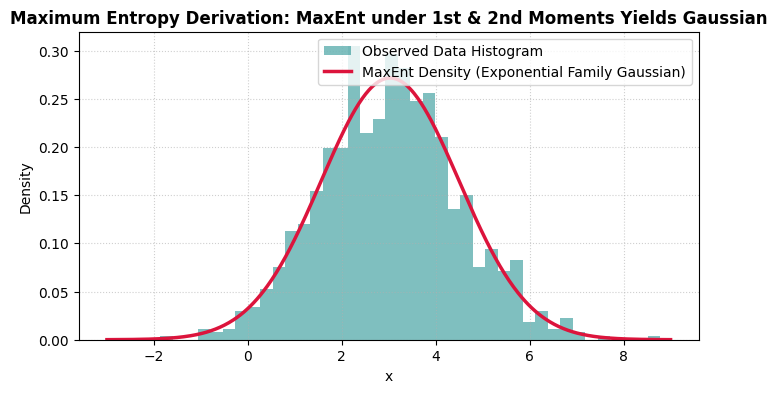

In [6]:
#Start code here..
#Numerical Max entropy optimization: Fitting gaussian via 1st and 2nd moment constraints
np.random.seed(42)
data_obs = np.random.normal(loc=3.0, scale=1.5, size=1000)
alpha1_obs = np.mean(data_obs)
alpha2_obs = np.mean(data_obs**2)

grid_x = np.linspace(-3,9,500)
#Objective function: Find the lagrange multipliers lambda1, lambda2 to match the moments
def moment_residuals(lambdas):
    l1, l2 = lambdas
    #max entropy density
    unnorm_p = np.exp(-l1 * grid_x - l2 * (grid_x ** 2))
    Z = np.trapz(unnorm_p, grid_x)
    p_x = unnorm_p / Z

    exp_x = np.trapz(grid_x * p_x, grid_x)
    exp_x2 = np.trapz((grid_x**2) * p_x, grid_x)
    return [exp_x - alpha1_obs, exp_x2 - alpha2_obs]

#solve max entropy lagrange multiplers
sol_lambdas = opt.root(moment_residuals, [0.1, 0.1]).x
l1_opt, l2_opt = sol_lambdas

#Reconstruct the max entropy PDF
unnorm_maxent = np.exp(-l1_opt * grid_x - l2_opt * (grid_x ** 2))
Z_opt = np.trapz(unnorm_maxent, grid_x)
p_maxent = unnorm_p_maxent / Z_opt

#End code here..
plt.figure(figsize=(8, 4))
plt.hist(data_obs, bins=40, density=True, color='teal', alpha=0.5, label='Observed Data Histogram')
plt.plot(grid_x, p_maxent, color='crimson', linewidth=2.5, label='MaxEnt Density (Exponential Family Gaussian)')
plt.xlabel('x')
plt.ylabel('Density')
plt.title('Maximum Entropy Derivation: MaxEnt under 1st & 2nd Moments Yields Gaussian', fontweight='bold')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()


## 3️⃣ Mixture Models & Gaussian Mixture Models (GMM)

### 3.1 Convex Combination Mixture Formulation
A Mixture Model combines $K$ base distributions via mixture weights $\pi_k$:
$$P(\mathbf{y} \mid \boldsymbol{\theta}) = \sum_{k=1}^K \pi_k p_k(\mathbf{y} \mid \boldsymbol{\theta}_k), \quad \pi_k \ge 0, \quad \sum_{k=1}^K \pi_k = 1$$

### 3.2 Soft Responsibilities & K-Means Reduction
- **Soft Posterior Responsibility** $r_{nk} = P(z_n = k \mid \mathbf{y}_n)$:
  $$r_{nk} = \frac{\pi_k \mathcal{N}(\mathbf{y}_n \mid \boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k)}{\sum_{j=1}^K \pi_j \mathcal{N}(\mathbf{y}_n \mid \boldsymbol{\mu}_j, \boldsymbol{\Sigma}_j)}$$
- **K-Means Reduction**: When components are spherical ($\boldsymbol{\Sigma}_k = \sigma^2 \mathbf{I}$) and priors are uniform ($\pi_k = 1/K$), hard assignment $\hat{z}_n = \arg\max_k r_{nk}$ reduces exactly to **K-Means Clustering**:
  $$\hat{z}_n = \arg\min_k \|\mathbf{y}_n - \boldsymbol{\mu}_k\|^2$$


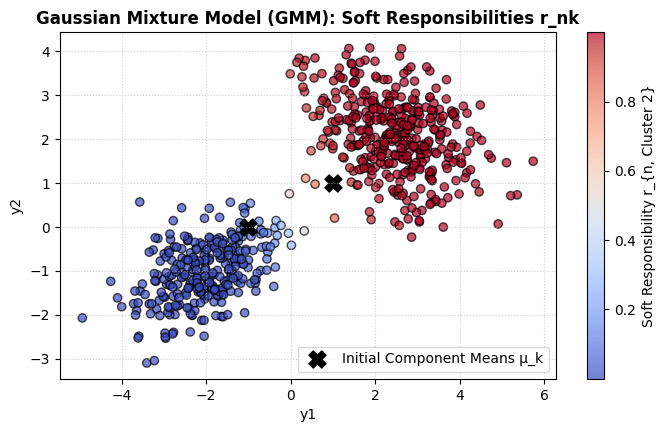

In [7]:
#Start code here..
#Code implementation of gaussian mixture model
np.random.seed(42)
c1 = np.random.multivariate_normal([-2.0, -1.0],[[0.8,0.3], [0.3,0.5]], size=300)
c2 = np.random.multivariate_normal([2.5, 2.0],[[1.0,-0.4], [-0.4,0.8]], size=400)
X_gmm = np.vstack([c1, c2])

#Initialize GMM parameters K = 2
K = 2
pi_k = np.array([0.5, 0.5])
mu_k = np.array([[-1.0, 0.0], [1.0, 1.0]])
Sigma_k = np.array([np.eye(2), np.eye(2)])

#Expectation step E-step : Compute the responsibilites r_nk
N = X_gmm.shape[0]
r_nk = np.zeros((N,K))
for k in range(K):
    r_nk[:, k] = pi_k[k] * stats.multivariate_normal(mu_k[k], Sigma_k[k]).pdf(X_gmm)
r_nk /= np.sum(r_nk, axis=1, keepdims=True)
#End code here..
plt.figure(figsize=(8, 4.5))
scatter = plt.scatter(X_gmm[:, 0], X_gmm[:, 1], c=r_nk[:, 1], cmap='coolwarm', alpha=0.7, edgecolor='k')
plt.colorbar(scatter, label='Soft Responsibility r_{n, Cluster 2}')
plt.scatter(mu_k[:, 0], mu_k[:, 1], color='black', marker='X', s=150, label='Initial Component Means μ_k')
plt.title('Gaussian Mixture Model (GMM): Soft Responsibilities r_nk', fontweight='bold')
plt.xlabel('y1')
plt.ylabel('y2')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()


## 4️⃣ Bernoulli Mixture Models (BMM)

### 4.1 Binary Data Mixture Formulation
For binary vector data $\mathbf{y} \in \{0, 1\}^D$ (e.g. MNIST digit pixel grids):
$$P(\mathbf{y} \mid \boldsymbol{\mu}_k) = \prod_{d=1}^D \mu_{dk}^{y_d} (1 - \mu_{dk})^{1 - y_d}$$
where $\mu_{dk}$ is the probability that bit $d$ is turned on in cluster $k$.

In [ ]:
#Start code here..


#End code here..

## 5️⃣ Probabilistic Graphical Models (PGMs) & Markov Chains

### 5.1 Directed Acyclic Graphs (DAGs) & Ordered Markov Property
A Probabilistic Graphical Model factorizes a high-dimensional joint distribution using graph structure:
$$P(y_1, y_2, \dots, y_D) = \prod_{i=1}^D P(y_i \mid \text{Parents}(y_i))$$

### 5.2 Markov Chains & N-Gram Language Models
- **First-Order Markov Chain**: $P(y_1, \dots, y_T) = P(y_1) \prod_{t=2}^T P(y_t \mid y_{t-1})$ (Bigram Language Model).
- **Second-Order Markov Chain**: $P(y_t \mid y_{t-1}, y_{t-2})$ (Trigram Language Model).

In [9]:
#Start code here....
#Code implementation of first-order markov chain(bigram transition matrix):
vocab = ['Probabilistic', 'Machine', 'Learning', 'Gaussians']
K_vocab = len(vocab)

#transition probability matrix P(y_t | y_{t-1})
trans_mat = np.array([
    [0.1, 0.7, 0.1, 0.1], #Probabilistic -> Machine (0.7)
    [0.1, 0.1, 0.7, 0.1], # Machine -> learning (0.7)
    [0.4, 0.1, 0.1, 0.4], #learning -> Probabilistic (0.4) / Gaussians (0.4)
    [0.5, 0.2, 0.2, 0.1] #gaussians -> Probabilistic (0.5)
])
#simulate sentence generation from markov chains
seq_len = 8
current_word_idx = 0
generated_sequence = [vocab[current_word_idx]]
for _ in range(seq_len - 1):
    next_word_idx = np.random.choice(K_vocab, p=trans_mat[current_word_idx])
    generated_sequence.append(vocab[next_word_idx])
    current_word_idx = next_word_idx

print("First order markov chain generated sequence:")
print("->".join(generated_sequence))

#End code here...


First order markov chain generated sequence:
Probabilistic->Machine->Machine->Probabilistic->Machine->Learning->Probabilistic->Probabilistic
